In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train.7z to train (1).7z
Saving trainLabels.csv to trainLabels.csv


In [ ]:
import os
import zipfile

os.makedirs('/content/data', exist_ok=True)

if os.path.exists('train.zip'):
    with zipfile.ZipFile('train.zip', 'r') as z:
        z.extractall('/content/data')
elif os.path.exists('train.7z'):
    !pip install py7zr -q
    import py7zr
    with py7zr.SevenZipFile('train.7z', mode='r') as z:
        z.extractall('/content/data')
else:
    raise FileNotFoundError("Couldn't find train.zip or train.7z in the uploaded files")

print(os.listdir('/content/data'))

['train']


In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split


candidates = [os.path.join('/content/data', d) for d in os.listdir('/content/data')]
train_img_dir = next((c for c in candidates if os.path.isdir(c)), '/content/data')
print(f"Reading images from: {train_img_dir}")

labels_df = pd.read_csv('trainLabels.csv')  # columns: id, label
labels_df = labels_df.sort_values('id').reset_index(drop=True)

class_names = sorted(labels_df['label'].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}

images, labels = [], []
for _, row in labels_df.iterrows():
    img_path = os.path.join(train_img_dir, f"{row['id']}.png")
    img = Image.open(img_path).convert('RGB')
    images.append(np.array(img))
    labels.append(label_to_idx[row['label']])

images = np.array(images, dtype='float32') / 255.0
labels = np.array(labels)
x_train, x_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, stratify=labels, random_state=42
)

print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")

Reading images from: /content/data/train
Train shape: (40000, 32, 32, 3), Test shape: (10000, 32, 32, 3)


In [ ]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [ ]:
from tensorflow.keras import regularizers

L2 = 1e-4

def conv_block(x, filters, dropout_rate):
    x = layers.Conv2D(filters, 3, padding='same', kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

def build_model():
    inputs = layers.Input(shape=(32, 32, 3))
    x = data_augmentation(inputs)

    x = conv_block(x, 32, 0.2)
    x = conv_block(x, 64, 0.3)
    x = conv_block(x, 128, 0.4)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    return models.Model(inputs, outputs)

model = build_model()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 324,394 (1.24 MB)

 Trainable params: 323,498 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=18, restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=64,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.7501 - loss: 0.8445 - val_accuracy: 0.6909 - val_loss: 1.2286 - learning_rate: 0.0010
Epoch 2/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7535 - loss: 0.8477 - val_accuracy: 0.7455 - val_loss: 0.8847 - learning_rate: 0.0010
Epoch 3/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7535 - loss: 0.8500 - val_accuracy: 0.7416 - val_loss: 0.9122 - learning_rate: 0.0010
Epoch 4/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.7542 - loss: 0.8523 - val_accuracy: 0.7220 - val_loss: 0.9852 - learning_rate: 0.0010
Epoch 5/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7564 - loss: 0.8428 - val_accuracy: 0.7749 - val_loss: 0.8177 - learning_rate: 0.0010
Epoch 6/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.7589 - loss: 0.8477 - val_accuracy: 0.7697 - val_loss: 0.8739 - learning_rate: 0.0010
Epoch 7/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.7631 - l

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8397 - loss: 0.5911
Test accuracy: 0.8397
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

    airplane       0.87      0.89      0.88      1000
  automobile       0.91      0.92      0.92      1000
        bird       0.84      0.77      0.80      1000
         cat       0.78      0.62      0.70      1000
        deer       0.86      0.82      0.84      1000
         dog       0.82      0.71      0.76      1000
        frog       0.75      0.94      0.83      1000
       horse       0.84      0.86      0.85      1000
        ship       0.92      0.92      0.92      1000
       truck       0.81      0.95      0.88      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



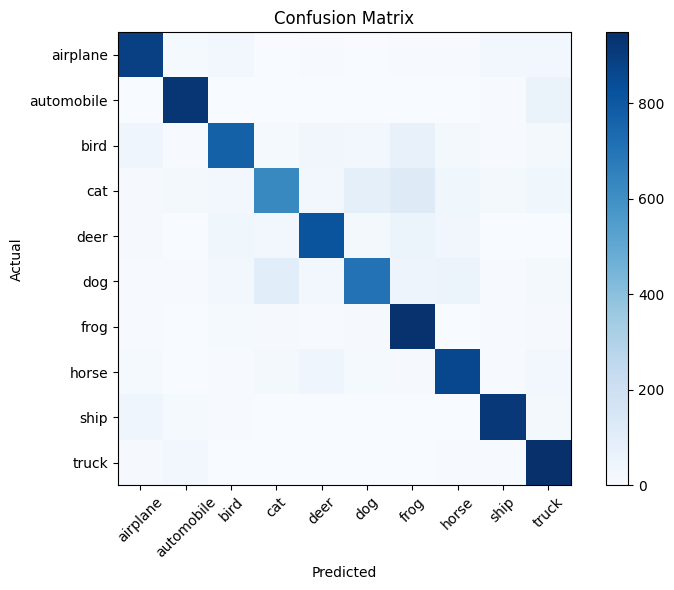

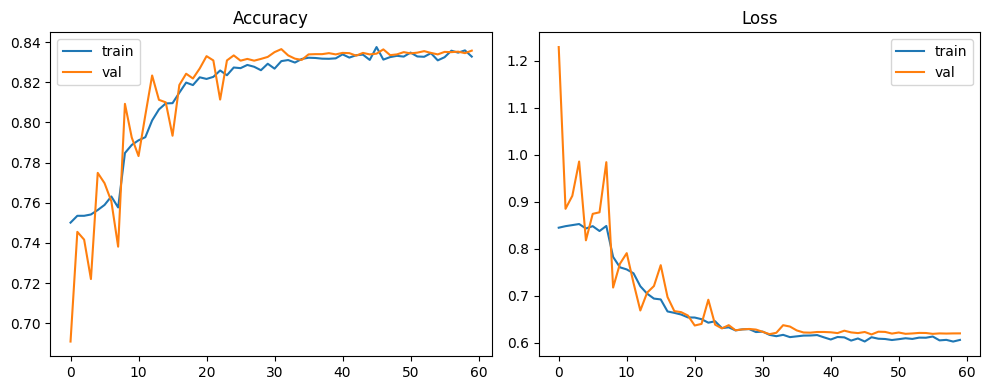

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(x_test), axis=1)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('training_curves.png')

In [ ]:
model.save('image_tagging_model.keras')

def tag_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(32, 32))
    arr = tf.keras.utils.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    pred = model.predict(arr)
    return class_names[np.argmax(pred)]